### Geographic Distance Notebook for Development Testing

In [84]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from ecd_helperFunctions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
# Load in CSV as dataframe
sample_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S2.csv')

# Calculate GD for each ROI
gd, cell_count_dict,bboxes, mantel_dict = calculate_gd(df=sample_df, 
                            perturb_matrix=True,
                            return_bboxes=True,
                            roi_tile_size=500)

print(bboxes)
print(gd)
print(mantel_dict)
print(cell_count_dict)


/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Group the cells by grid indices


Calculating perturbed intensity matrix for ROI:  (63, 5) for  0  of  23  ROIs
Calculating perturbed intensity matrix for ROI:  (63, 6) for  1  of  23  ROIs
0.15926989184507248
Calculating perturbed intensity matrix for ROI:  (63, 7) for  2  of  23  ROIs
0.1819792181075014
Calculating perturbed intensity matrix for ROI:  (63, 8) for  3  of  23  ROIs
0.9999943134032204
Calculating perturbed intensity matrix for ROI:  (64, 4) for  4  of  23  ROIs
0.0924199122334036
Calculating perturbed intensity matrix for ROI:  (64, 5) for  5  of  23  ROIs
-0.011242113551482103
Calculating perturbed intensity matrix for ROI:  (64, 6) for  6  of  23  ROIs
0.025447432352055634
Calculating perturbed intensity matrix for ROI:  (64, 7) for  7  of  23  ROIs
0.200899684381187
Calculating perturbed intensity matrix for ROI:  (64, 8) for  8  of  23  ROIs
0.4160442388205706
Calculating perturbed intensity matrix for ROI:  (65, 3) for  9  of  23  ROIs
0.05586595757534206
Calculating perturbed intensity matrix for 

Adjusted explanation value range: -0.041694110551345046 to 0.4050994766856817


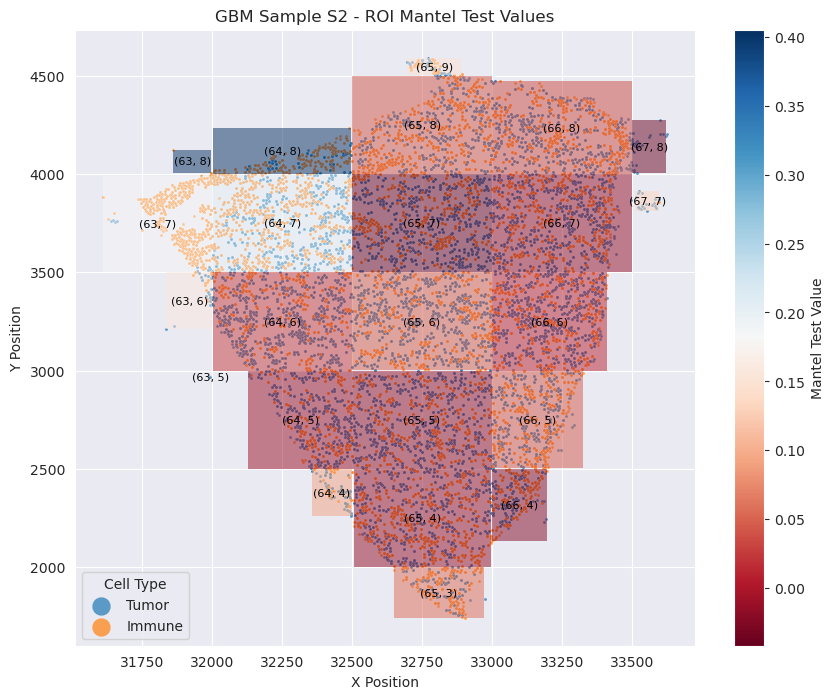

In [83]:
# Plot Heatmap with Explainer Values

# Define custom legend and scatter plot options
legend_options = {
    'title': 'Cell Type',
    'markerscale': 6,
    'loc': 'lower left',
    'fontsize': 10
}

scatter_options = {
    's': 5,
    'zorder': 2,
    'alpha': 0.7  # Additional scatter plot options
}

# Call the function with custom options
plot_roi_explanations(
    data_dict=mantel_dict,
    sample_df=sample_df,
    bboxes=bboxes,
    legend_kwargs=legend_options,
    scatter_kwargs=scatter_options,
    title='GBM Sample S2 - ROI Mantel Test Values',
    save_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/heatmaps/s2_smallroi_cell_positions_with_mantel_values.png',
    dpi=300,
    bbox_inches='tight'
)


In [87]:
immune_cell_count = cell_count_dict[1]   
tumor_cell_count = cell_count_dict[0]
# Calculate the weighted statistic
weighted_statistic = compute_weighted_statistic(statistics=mantel_dict.values(),
                                                  cell_counts_type_A=immune_cell_count,
                                                  cell_counts_type_B=tumor_cell_count)

print(weighted_statistic)

0.06324290903302555
